In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [15]:
# Write your code here
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# more plotly imports
from plotly.offline import init_notebook_mode, iplot, plot
init_notebook_mode(connected=True)
import plotly as py
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots


# load main dataset
df = pd.read_csv('./drive/MyDrive/games_march2025_cleaned.csv', engine='python', on_bad_lines='skip')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


In [56]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, f1_score
from sklearn.pipeline import Pipeline

In [18]:
# Select useful columns
columns_to_keep = [
    'name', 'release_date', 'required_age', 'price', 'dlc_count',
    'detailed_description', 'metacritic_score', 'recommendations',
    'genres', 'categories',
    'positive', 'negative', 'estimated_owners',
    'average_playtime_forever', 'median_playtime_forever', 'peak_ccu',
    'tags', 'pct_pos_total', 'num_reviews_total'
]

# Create a filtered version of the dataframe
df_ml = df[columns_to_keep].copy()
df = df_ml.dropna(subset=['detailed_description'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 89421 entries, 0 to 89617
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      89421 non-null  object 
 1   release_date              89421 non-null  object 
 2   required_age              89421 non-null  int64  
 3   price                     89421 non-null  float64
 4   dlc_count                 89421 non-null  int64  
 5   detailed_description      89421 non-null  object 
 6   metacritic_score          89421 non-null  int64  
 7   recommendations           89421 non-null  int64  
 8   genres                    89421 non-null  object 
 9   categories                89421 non-null  object 
 10  positive                  89421 non-null  int64  
 11  negative                  89421 non-null  int64  
 12  estimated_owners          89421 non-null  object 
 13  average_playtime_forever  89421 non-null  int64  
 14  median_play

,name,release_date,required_age,price,dlc_count,detailed_description,metacritic_score,recommendations,genres,categories,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,peak_ccu,tags,pct_pos_total,num_reviews_total
0,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...",0,4401572,"['Action', 'Free To Play']","['Multi-player', 'Cross-Platform Multiplayer',...",7480813,1135108,100000000 - 200000000,33189,5174,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939
1,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",0,1732007,"['Action', 'Adventure', 'Massively Multiplayer...","['Multi-player', 'PvP', 'Online PvP', 'Stats',...",1487960,1024436,50000000 - 100000000,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842
2,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...",90,14337,"['Action', 'Strategy', 'Free To Play']","['Multi-player', 'Co-op', 'Steam Trading Cards...",1998462,451338,200000000 - 500000000,43031,898,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595
3,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...",96,1803063,"['Action', 'Adventure']","['Single-player', 'Multi-player', 'PvP', 'Onli...",1719950,250012,50000000 - 100000000,19323,7101,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832
4,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,0,1165929,['Action'],"['Single-player', 'Multi-player', 'PvP', 'Onli...",1152763,218446,20000000 - 50000000,14204,2434,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020


,metacritic_score
count,3538.000000
mean,73.339175
std,10.223056
min,20.000000
25%,68.000000
50%,75.000000
75%,81.000000
max,97.000000


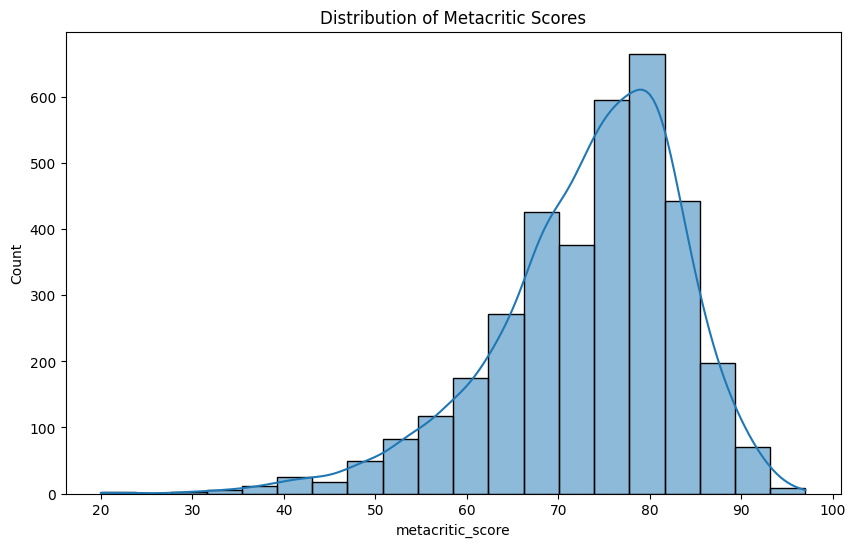

<class 'pandas.core.frame.DataFrame'>
Index: 3538 entries, 2 to 89245
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      3538 non-null   object 
 1   release_date              3538 non-null   object 
 2   required_age              3538 non-null   int64  
 3   price                     3538 non-null   float64
 4   dlc_count                 3538 non-null   int64  
 5   detailed_description      3538 non-null   object 
 6   metacritic_score          3538 non-null   int64  
 7   recommendations           3538 non-null   int64  
 8   genres                    3538 non-null   object 
 9   categories                3538 non-null   object 
 10  positive                  3538 non-null   int64  
 11  negative                  3538 non-null   int64  
 12  estimated_owners          3538 non-null   object 
 13  average_playtime_forever  3538 non-null   int64  
 14  median_playt

,name,release_date,required_age,price,dlc_count,detailed_description,metacritic_score,recommendations,genres,categories,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,peak_ccu,tags,pct_pos_total,num_reviews_total
2,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...",90,14337,"['Action', 'Strategy', 'Free To Play']","['Multi-player', 'Co-op', 'Steam Trading Cards...",1998462,451338,200000000 - 500000000,43031,898,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595
3,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...",96,1803063,"['Action', 'Adventure']","['Single-player', 'Multi-player', 'PvP', 'Onli...",1719950,250012,50000000 - 100000000,19323,7101,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832
5,Team Fortress 2,2007-10-10,0,0.00,1,'The most fun you can have online' - PC Gamer ...,92,41587,"['Action', 'Free To Play']","['Multi-player', 'Cross-Platform Multiplayer',...",1025633,120619,20000000 - 50000000,0,0,50817,"{'Free to Play': 62868, 'Hero Shooter': 61020,...",89,1146642
6,Terraria,2011-05-16,0,9.99,2,"Dig, Fight, Explore, Build: The very world is ...",83,1098792,"['Action', 'Adventure', 'Indie', 'RPG']","['Single-player', 'Multi-player', 'PvP', 'Onli...",1344773,34460,20000000 - 50000000,0,0,30516,"{'Open World Survival Craft': 16365, 'Sandbox'...",97,1102434
7,Rust,2018-02-08,0,39.99,4,The only aim in Rust is to survive. Everything...,69,992825,"['Action', 'Adventure', 'Indie', 'Massively Mu...","['Multi-player', 'MMO', 'PvP', 'Online PvP', '...",1043708,152272,20000000 - 50000000,21195,3675,200902,"{'Survival': 18592, 'Crafting': 11822, 'Multip...",87,993856


In [19]:
# Filter the dataframe to only include games with a Metacritic score
df_rated = df[df['metacritic_score'] > 0].copy()
display(df_rated['metacritic_score'].describe())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df_rated['metacritic_score'], bins=20, kde=True)
plt.title('Distribution of Metacritic Scores')
plt.show()
df_rated.info()
df_rated.head()

# Use df_rated for machine learning on Metacritic scores, df for other models

In [20]:
df_rated = df_rated.copy()

# create new feature
df_rated['positive_ratio'] = df_rated['positive'] / (df_rated['positive'] + df_rated['negative'])

# classification label
df_rated['player_label'] = df_rated['positive_ratio'].apply(lambda x: 1 if x >= 0.7 else 0)

features = ['price', 'peak_ccu', 'num_reviews_total', 'metacritic_score']

df_rated = df_rated.dropna(subset=features)

X = df_rated[features]
y = df_rated['player_label']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [57]:
features = ['price', 'peak_ccu', 'num_reviews_total', 'metacritic_score', 'average_playtime_forever']

df_prices = df.copy()

df_prices['positive_ratio'] = df_prices['positive'] / (df_prices['positive'] + df_prices['negative'])
df_prices['player_label'] = df_prices['positive_ratio'].apply(lambda x: 1 if x >= 0.7 else 0)

df_prices = df_prices.dropna(subset=features)

X = df_prices[features]
y = df_prices['player_label']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Added random_state for reproducibility

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000)) # Increased max_iter for convergence
])

# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

# Make predictions on the test set using the pipeline
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.0%}")
print(f"Model F1-Score: {f1:.0%}")

# Optional: print confusion matrix
# cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()
# print("Confusion Matrix:")
# print(cm)
(tn, fp, fn, tp)

Model Accuracy: 55%
Model F1-Score: 71%


(1, 8094, 2, 9788)

In [58]:
# Model Accuracy
accuracy_score = accuracy
print(f"Model Accuracy: {accuracy_score:.0%}")

# Model F1-Score
f1_score_value = f1
print(f"Model F1-Score: {f1_score_value:.0%}")

# Confusion Matrix components
true_positives = tp
true_negatives = tn
false_positives = fp
false_negatives = fn

print(f"True Positives (TP): {true_positives}")
print(f"True Negatives (TN): {true_negatives}")
print(f"False Positives (FP): {false_positives}")
print(f"False Negatives (FN): {false_negatives}")

Model Accuracy: 55%
Model F1-Score: 71%
True Positives (TP): 9788
True Negatives (TN): 1
False Positives (FP): 8094
False Negatives (FN): 2


<!-- The model's metrics provide insights into its performance:

*   **Accuracy (55%)**: This indicates that the model correctly predicted the `player_label` (whether a game has a high positive review ratio) for 55% of the games in the test set. While 55% is better than random (which would be 50%), it suggests there's room for improvement, as many predictions are still incorrect.

*   **F1-Score (71%)**: The F1-Score is a harmonic mean of precision and recall. It's often a better measure than accuracy for imbalanced datasets (where one class has many more samples than another). A 71% F1-Score suggests a reasonably good balance between precision (how many selected items are relevant) and recall (how many relevant items are selected) for predicting games with high positive review ratios. This is a more encouraging sign than the accuracy alone, indicating that the model isn't just trivially predicting the majority class. -->

Game prices don't seem to impact the scores of games too much. Based on the price distribution for good and bad games, there always seem to be an overlap between the two classes, despite the prices being different. However, based on the F1-score, the model appears to surprisingly perform moderately well on classifying games based on their price.

### Distribution of Game Prices
Let's visualize the distribution of game prices to understand the price categories of games in our dataset.

### Model's Categorization of Games by Price
Let's visualize how the model classifies games as 'good' (player_label = 1) or 'bad' (player_label = 0) based on their price. This scatter plot will show the distribution of prices for each category.

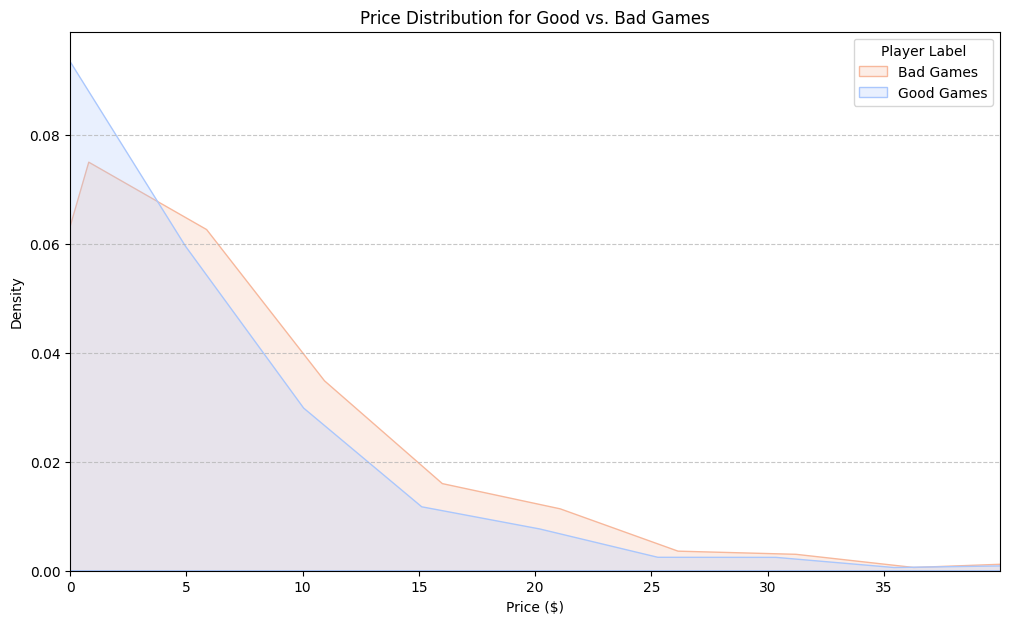

In [45]:
plt.figure(figsize=(12, 7))
sns.kdeplot(data=df_prices, x='price', hue='player_label', fill=True, common_norm=False, palette='coolwarm')
plt.title('Price Distribution for Good vs. Bad Games')
plt.xlabel('Price ($)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, df_prices['price'].quantile(0.99)) # Limit x-axis to 99th percentile for better visualization
plt.legend(title='Player Label', labels=['Bad Games', 'Good Games'])
plt.show()